In [33]:
import pickle
import os
import sys
import pandas as pd

In [34]:
with open("../../data/weather/dict_weather_raw_per_year.pk1", "rb") as f:
    data_per_year = pickle.load(f)

# Se eliminan los outliers
Se han identificado en:
- relative_humidity
- temperature

In [35]:
for year, stations in data_per_year.items():
    for station, df in stations.items():
        # Clonamos para no modificar el original
        item = df.copy()

        if 'relative_humidity' in item.columns:
            item.loc[(item['relative_humidity'] < 0) | (item['relative_humidity'] > 100), 'relative_humidity'] = pd.NA
            
        if 'temperature' in item.columns:
            item.loc[(item['temperature'] < -40) | (item['temperature'] > 50), 'temperature'] = pd.NA
        
        # Guardar limpio
        data_per_year[year][station] = item


# Analisis de NaN

In [36]:
for year, stations in data_per_year.items():
    print(f"=== Año {year} ===")
    for station, df in stations.items():
        print(f"--- Estación {station} ---")
        nulos = df.isna().sum()  # cuenta nulos por columna
        print(nulos)
        print()


=== Año 2022 ===
--- Estación USW00004807 ---
STATION                       0
Station_name                  0
DATE                          0
LATITUDE                      0
LONGITUDE                     0
temperature                 231
wind_speed                   10
precipitation             13274
relative_humidity           354
snow_depth                13509
station_level_pressure      471
dtype: int64

--- Estación USW00014819 ---
STATION                       0
Station_name                  0
DATE                          0
LATITUDE                      0
LONGITUDE                     0
temperature                   0
wind_speed                    3
precipitation              2981
relative_humidity             0
snow_depth                11801
station_level_pressure      762
dtype: int64

--- Estación USW00094846 ---
STATION                       0
Station_name                  0
DATE                          0
LATITUDE                      0
LONGITUDE                     0
temp

In [37]:
for year, stations in data_per_year.items():
    print(f"=== Año {year} ===")
    for station, df in stations.items():
        print(f"--- Estación {station} ---")
        
        porcentaje_nulos = df.isna().mean() * 100
        print(porcentaje_nulos.round(2))  # redondea a 2 decimales
        print()


=== Año 2022 ===
--- Estación USW00004807 ---
STATION                     0.00
Station_name                0.00
DATE                        0.00
LATITUDE                    0.00
LONGITUDE                   0.00
temperature                 1.71
wind_speed                  0.07
precipitation              98.26
relative_humidity           2.62
snow_depth                100.00
station_level_pressure      3.49
dtype: float64

--- Estación USW00014819 ---
STATION                    0.00
Station_name               0.00
DATE                       0.00
LATITUDE                   0.00
LONGITUDE                  0.00
temperature                0.00
wind_speed                 0.03
precipitation             24.86
relative_humidity          0.00
snow_depth                98.40
station_level_pressure     6.35
dtype: float64

--- Estación USW00094846 ---
STATION                    0.00
Station_name               0.00
DATE                       0.00
LATITUDE                   0.00
LONGITUDE            

## En las columnas de precipitacion y nieve se considera un NaN como un 0

In [38]:
cols_to_fill = ['precipitation', 'snow_depth']

for year, stations in data_per_year.items():
    for station, df in stations.items():
        item = df.copy()
        
        # Solo columnas que existan en el DataFrame
        valid_cols = [col for col in cols_to_fill if col in item.columns]
        
        item[valid_cols] = item[valid_cols].fillna(0)
        
        # Guardamos de nuevo
        data_per_year[year][station] = item


# Cambiar NaN por 0

In [39]:
# for year, stations in data_per_year.items():
#     for station, df in stations.items():
#         item = df.copy()
#         item = item.fillna(0)
#         data_per_year[year][station] = item


# Se ordenan los datos

In [40]:
for year, stations in data_per_year.items():
    for station, df in stations.items():
        df = df.sort_values('DATE')

# Se interpolan los datos

In [41]:

data_weather_interpolated = {}

for year, stations in data_per_year.items():
    print(f"Interpolando año {year}...")
    data_weather_interpolated[year] = {}
    
    for station, df in stations.items():
        item = df.copy()

        # Aseguramos formato de fecha correcto
        item['DATE'] = pd.to_datetime(item['DATE'], errors='coerce')
        item = item.sort_values('DATE').dropna(subset=['DATE'])

        # Crear índice completo con frecuencia 1 minuto ('1T')
        full_index = pd.date_range(start=item['DATE'].min(), end=item['DATE'].max(), freq='1T')

        # Reindexar y luego interpolar por tiempo
        item = item.set_index('DATE').reindex(full_index)
        item = item.interpolate(method='time')

        # Restaurar columna DATE
        item = item.reset_index().rename(columns={'index': 'DATE'})

        # Guardar en la misma estructura
        data_weather_interpolated[year][station] = item


Interpolando año 2022...


C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(start=item['DATE'].min(), end=item['DATE'].max(), freq='1T')
C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  item = item.interpolate(method='time')
C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(start=item['DATE'].min(), end=item['DATE'].max(), freq='1T')
C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=Fals

Interpolando año 2023...


C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(start=item['DATE'].min(), end=item['DATE'].max(), freq='1T')
C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  item = item.interpolate(method='time')
C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(start=item['DATE'].min(), end=item['DATE'].max(), freq='1T')
C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=Fals

Interpolando año 2024...


C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(start=item['DATE'].min(), end=item['DATE'].max(), freq='1T')
C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  item = item.interpolate(method='time')
C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:15: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  full_index = pd.date_range(start=item['DATE'].min(), end=item['DATE'].max(), freq='1T')
C:\Users\burvu\AppData\Local\Temp\ipykernel_19012\4175926465.py:19: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=Fals

======= 2022 =======


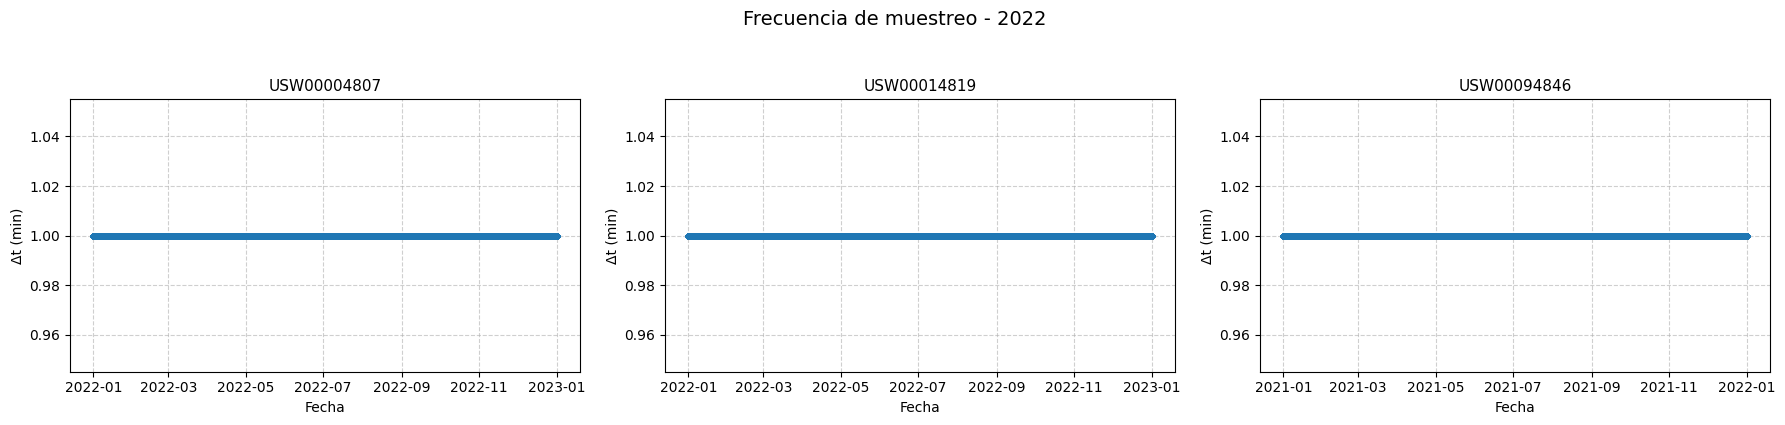

======= 2023 =======


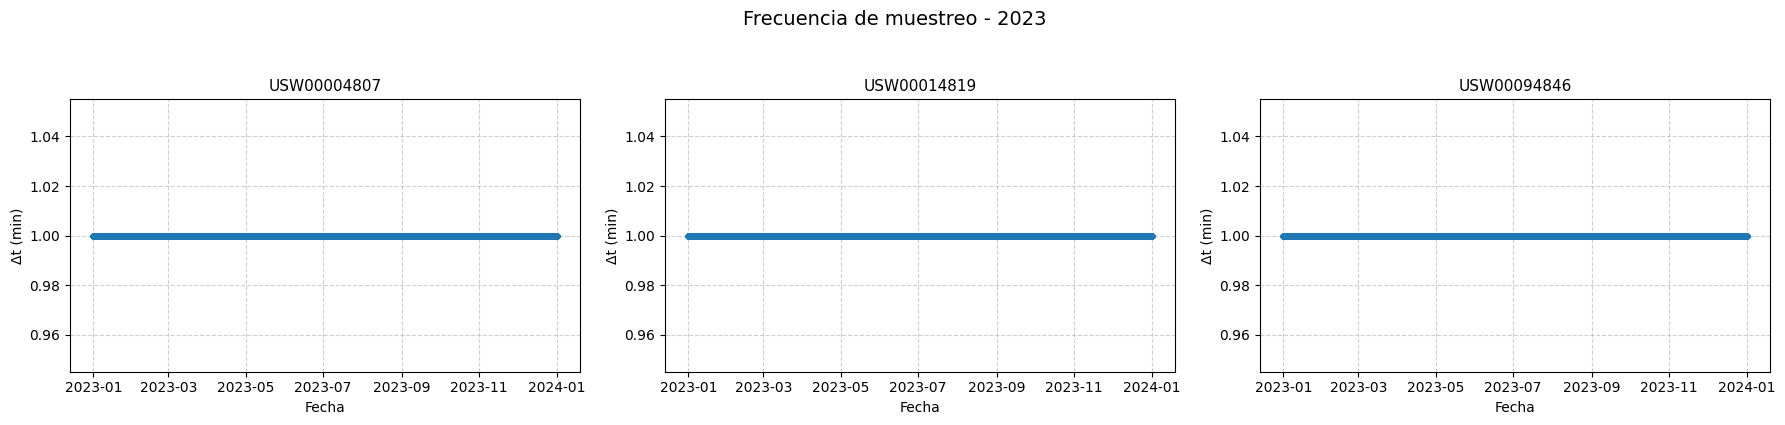

======= 2024 =======


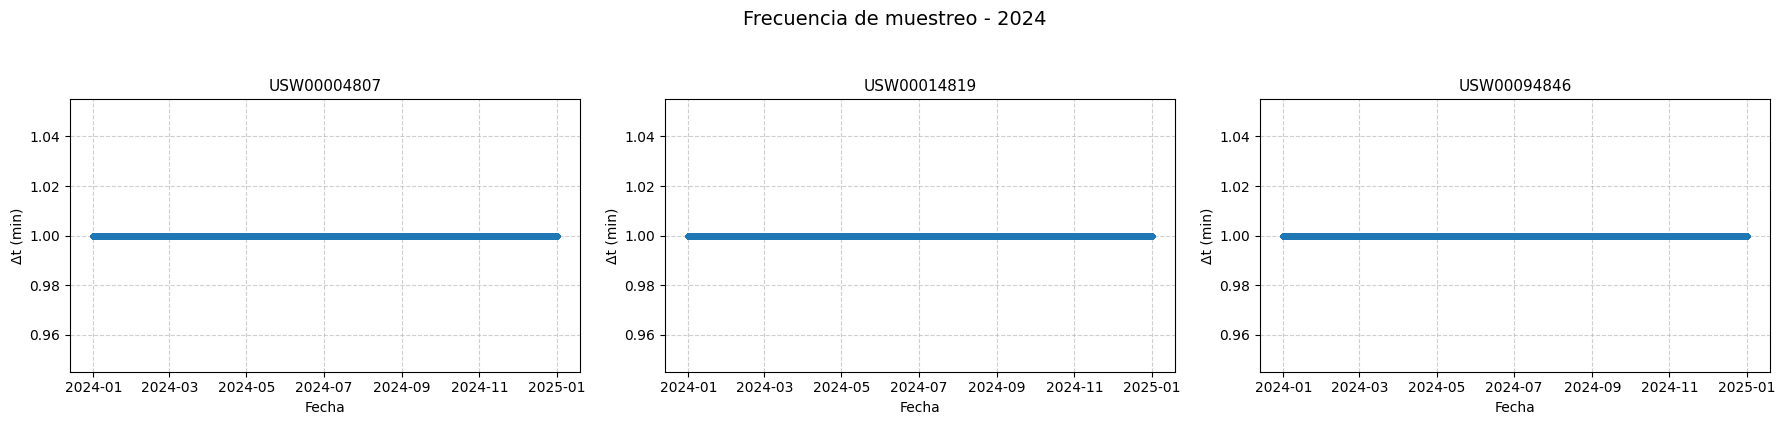

In [42]:
import matplotlib.pyplot as plt
import pandas as pd

for year, stations in data_weather_interpolated.items():
    print(f"======= {year} =======")

    station_names = list(stations.keys())
    num_stations = len(station_names)

    # Creamos una fila de subplots: una columna por estación
    fig, axes = plt.subplots(1, num_stations, figsize=(6 * num_stations, 4), sharex=False)
    
    # Si solo hay una estación, lo forzamos a lista para poder iterar
    if num_stations == 1:
        axes = [axes]

    for i, (station, df) in enumerate(stations.items()):
        df = df.copy()
        df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
        df = df.sort_values('DATE').dropna(subset=['DATE'])

        # Calcula diferencia temporal en minutos (puedes cambiar a horas si prefieres)
        df['Δt_min'] = df['DATE'].diff().dt.total_seconds() / 60

        ax = axes[i]
        ax.plot(df['DATE'], df['Δt_min'], marker='o', markersize=3, linestyle='-')
        ax.set_title(f'{station}', fontsize=11)
        ax.set_xlabel('Fecha')
        ax.set_ylabel('Δt (min)')
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.suptitle(f'Frecuencia de muestreo - {year}', fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()


In [43]:
cols = [
    "STATION",
    "Station_name",
    "DATE",
    "LATITUDE",
    "LONGITUDE",
    "temperature",
    "wind_speed",
    "precipitation",
    "relative_humidity",
    "snow_depth",
    "station_level_pressure"
]

======= 2022 =======


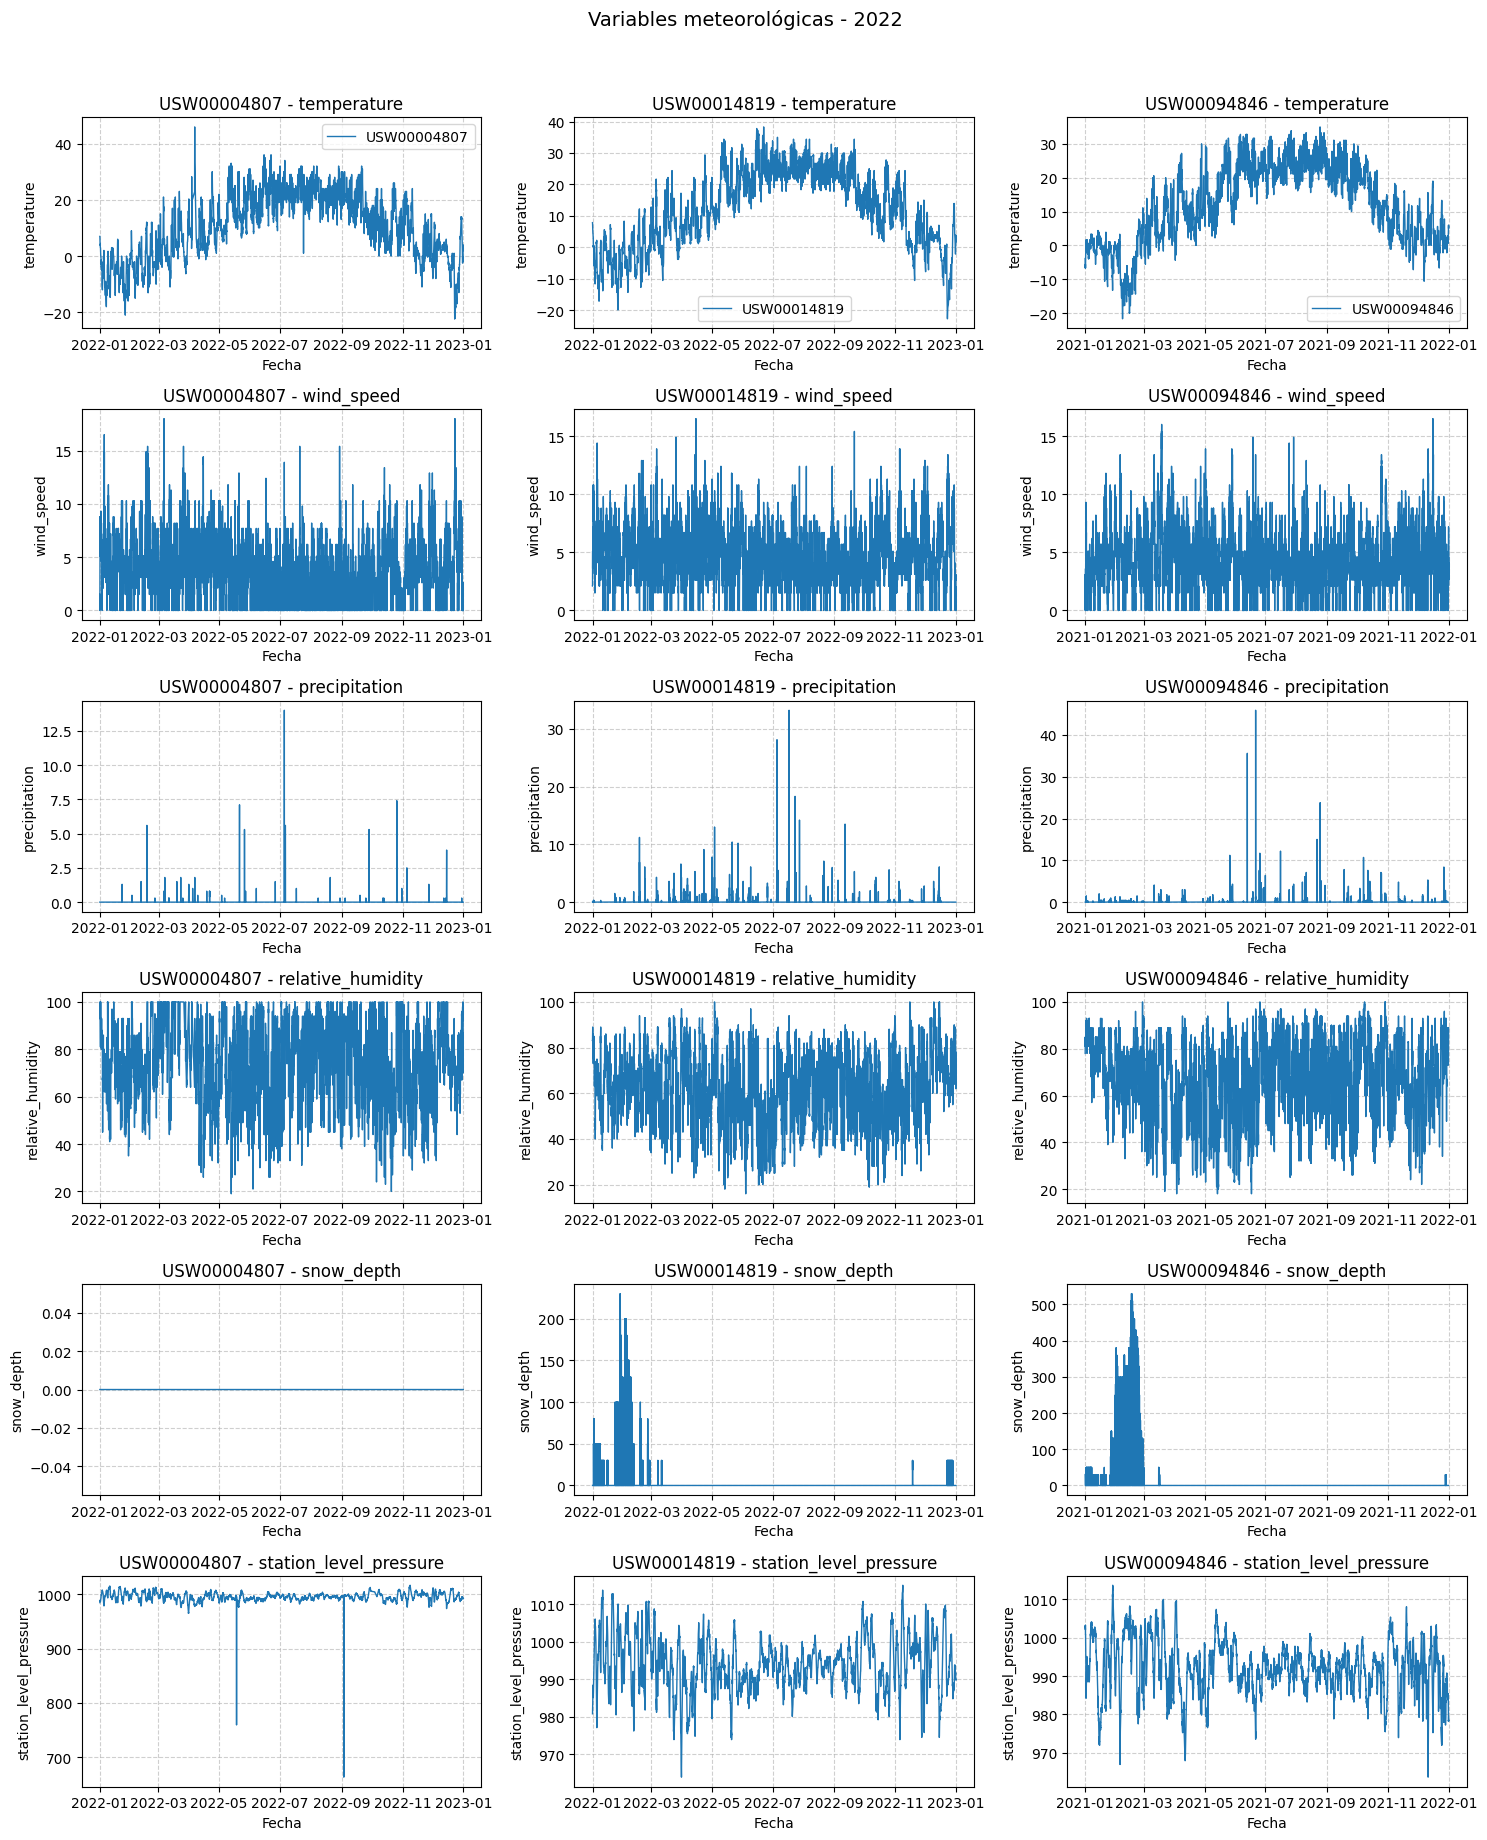

======= 2023 =======


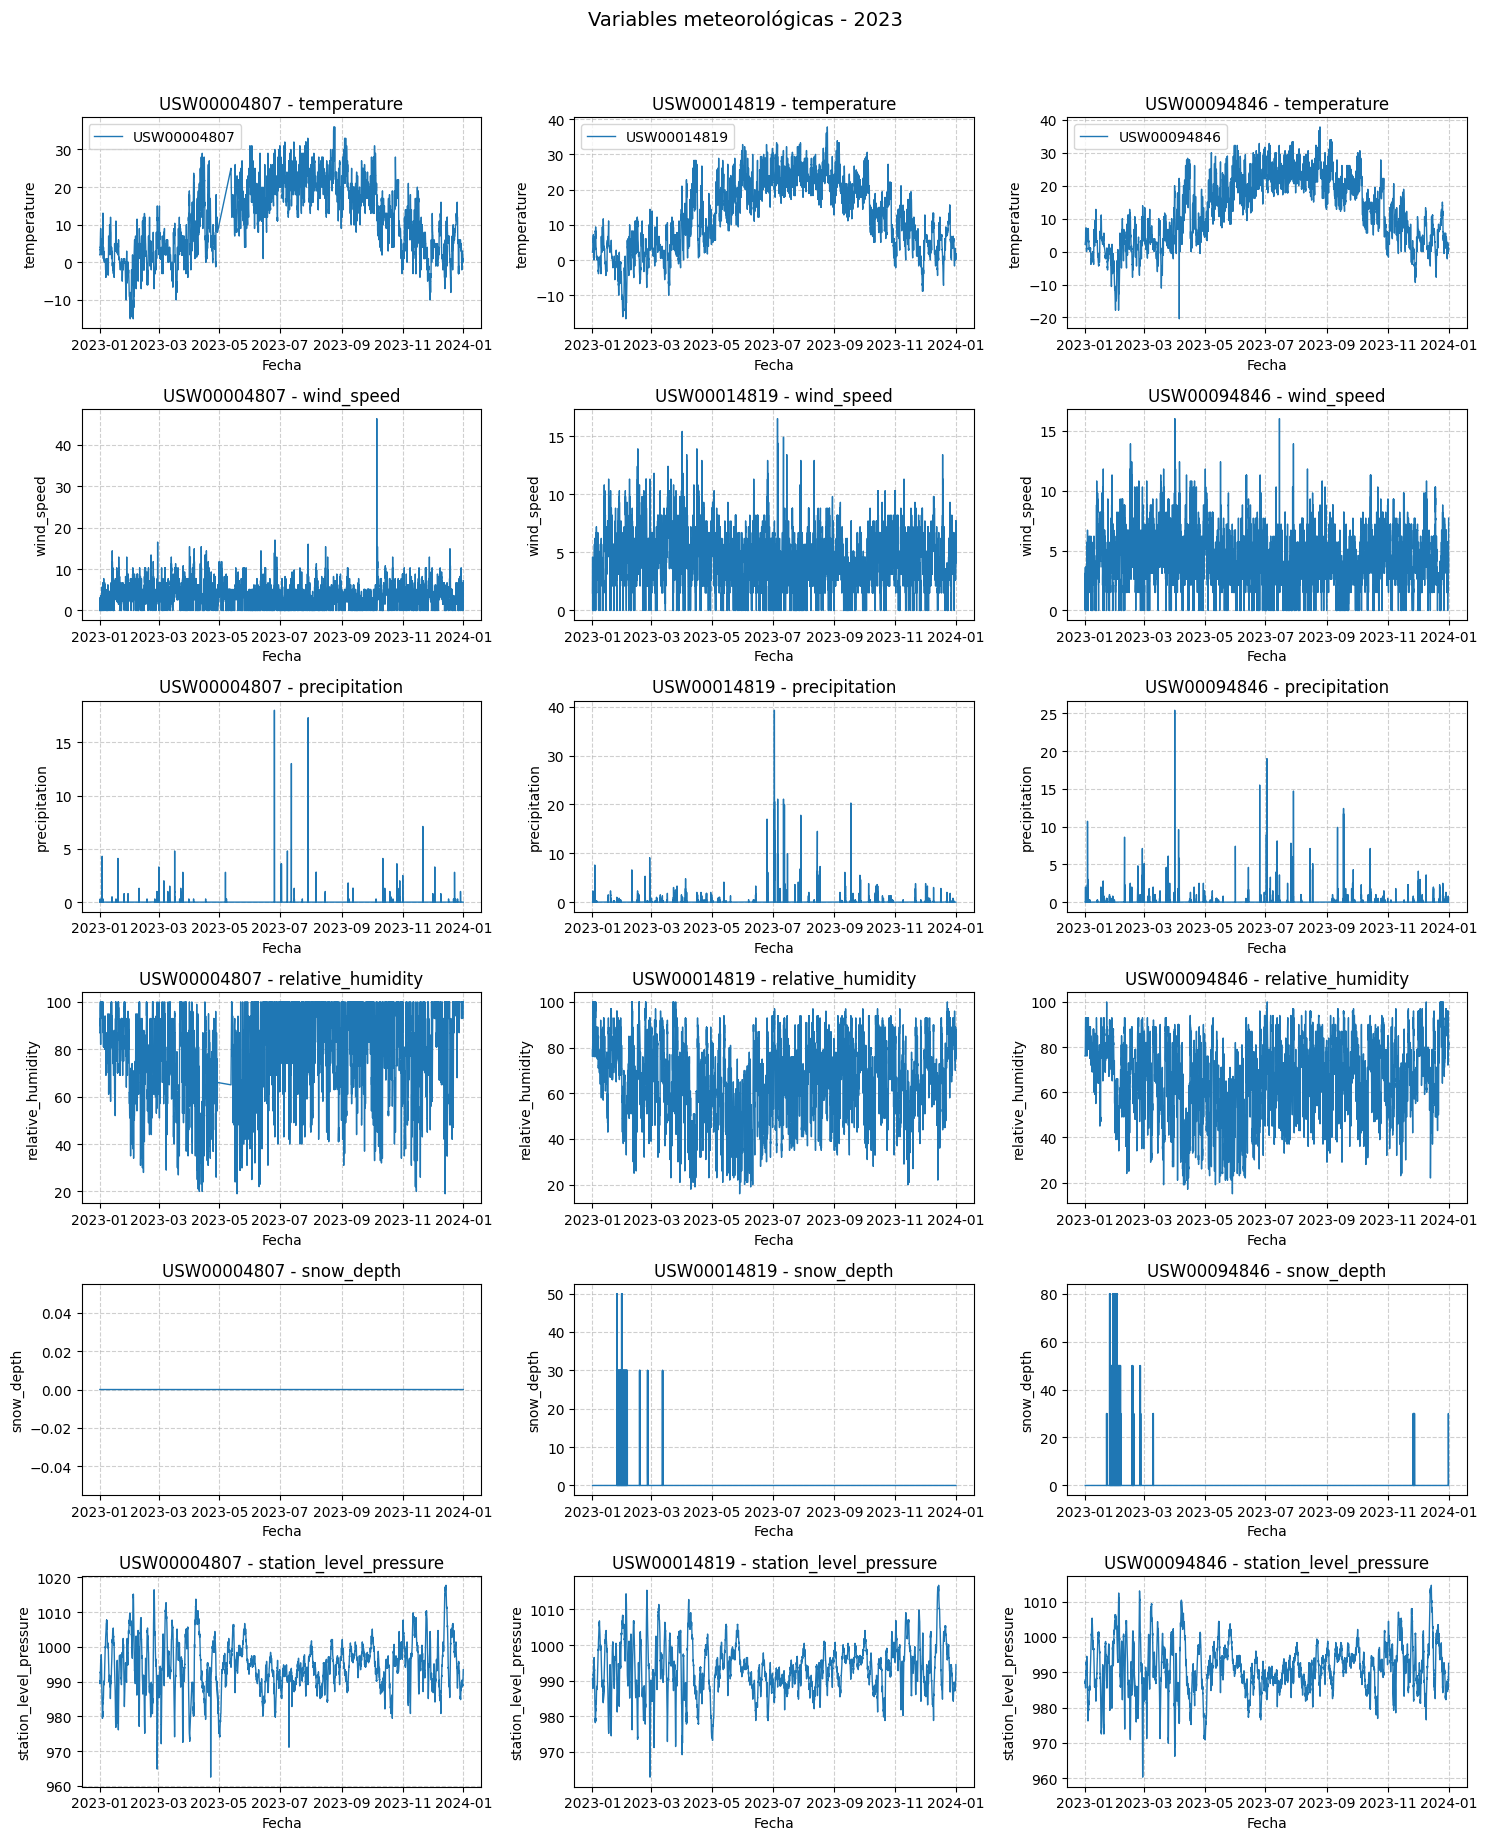

======= 2024 =======


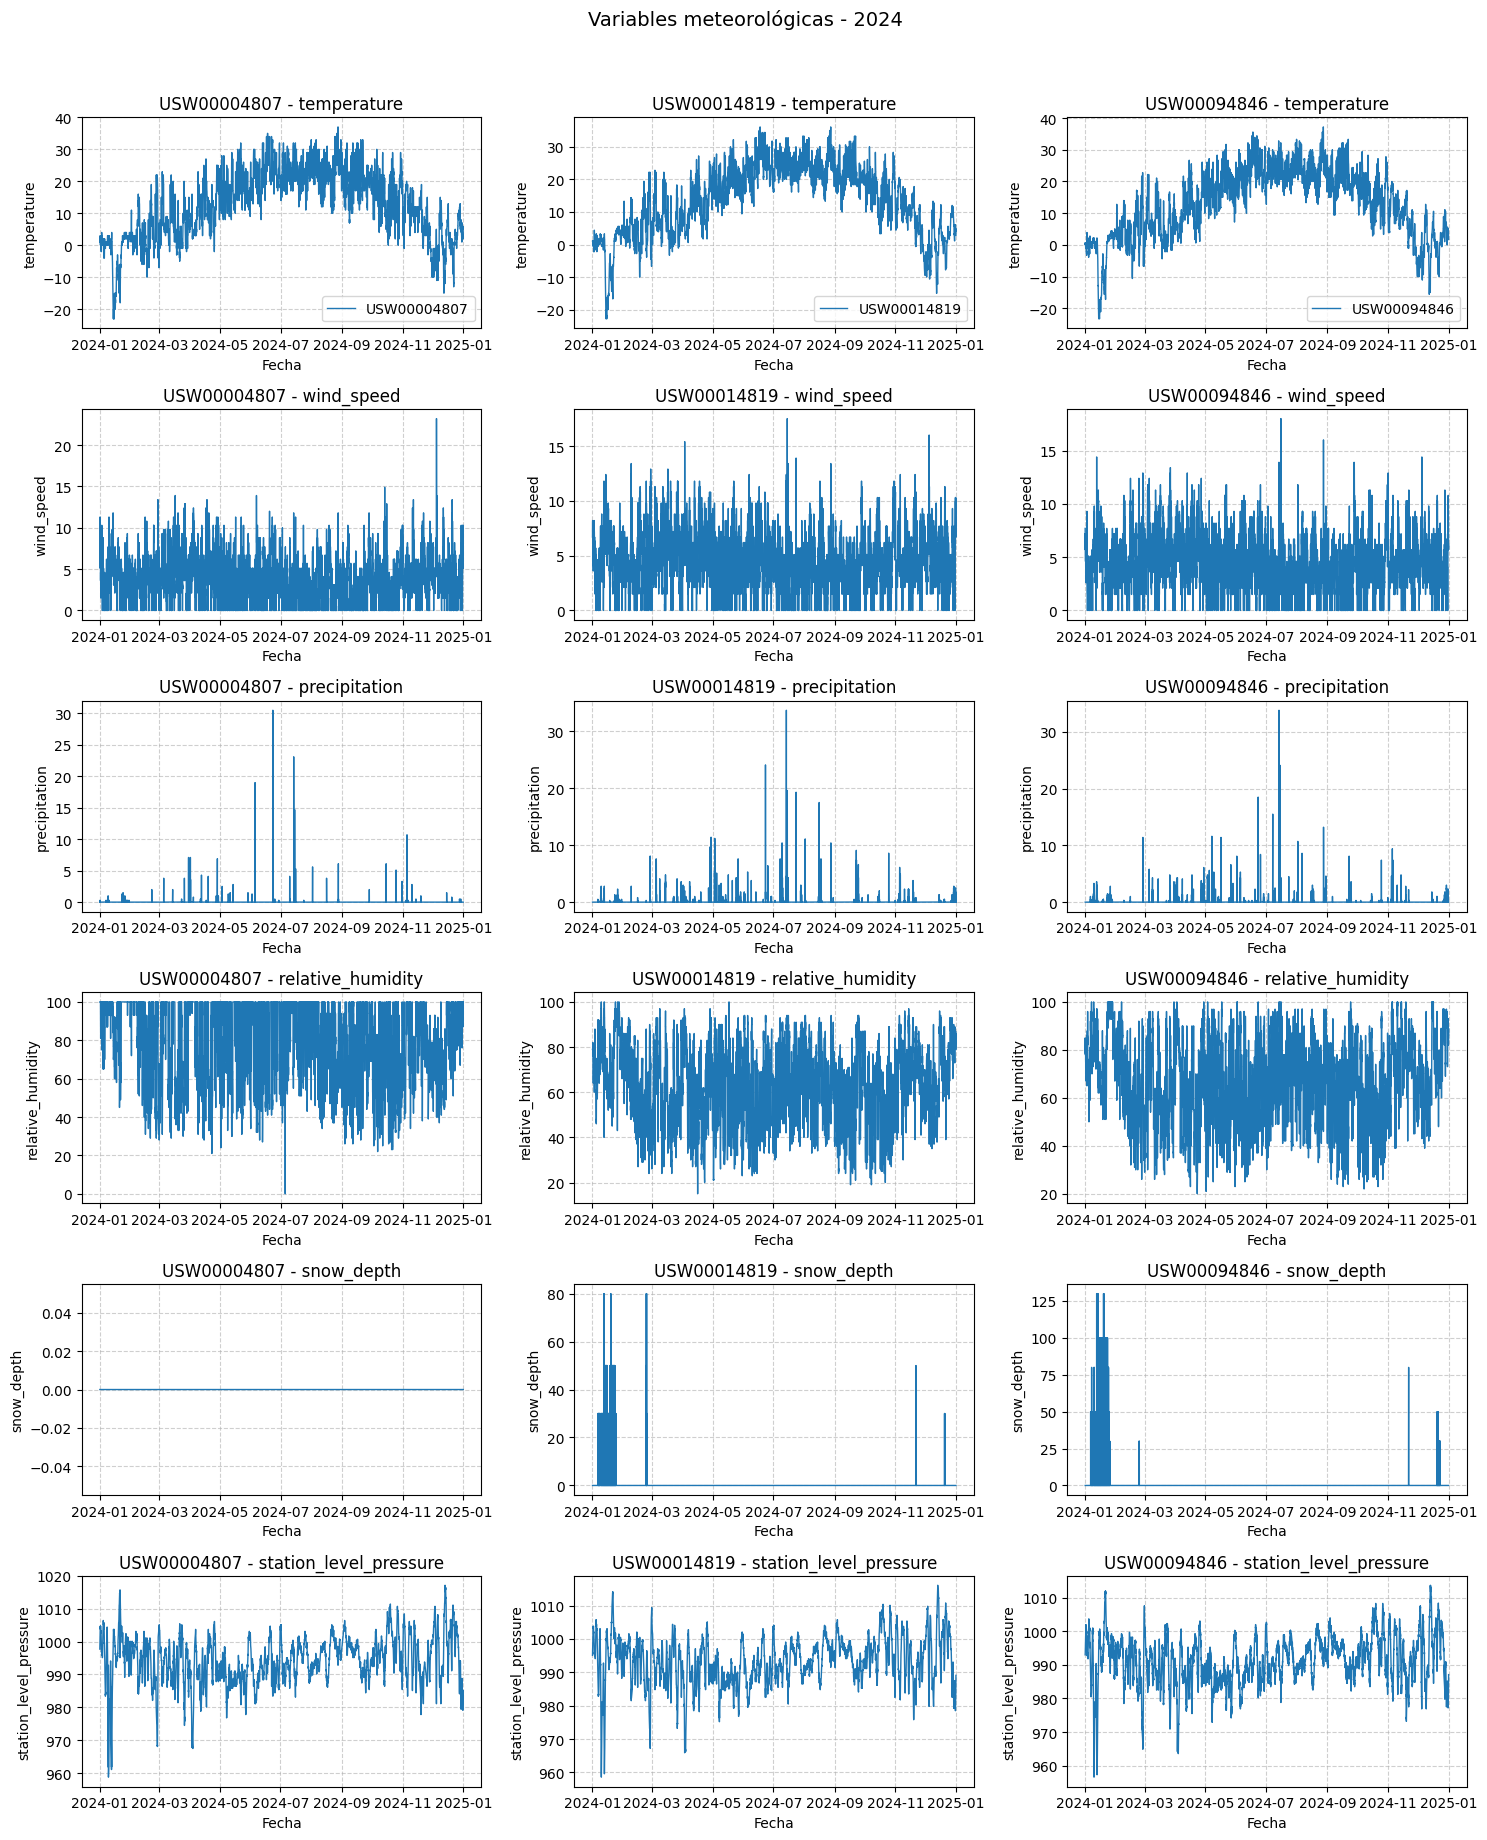

In [44]:
for year, stations in data_weather_interpolated.items():
    print(f"======= {year} =======")
    
    # Lista de estaciones y número
    station_names = list(stations.keys())
    num_stations = len(station_names)

    # Filtramos las columnas que queremos graficar (p. ej. a partir de la 6ª)
    vars_to_plot = cols[5:]
    num_vars = len(vars_to_plot)

    # Creamos figura: filas = variables, columnas = estaciones
    fig, axes = plt.subplots(num_vars, num_stations, figsize=(5*num_stations, 3*num_vars), sharex=False)
    
    # Si solo hay una estación o una variable, hacemos que axes sea 2D siempre
    if num_vars == 1 and num_stations == 1:
        axes = [[axes]]
    elif num_vars == 1:
        axes = [axes]
    elif num_stations == 1:
        axes = [[ax] for ax in axes]

    # Recorremos variables (filas)
    for row_idx, var in enumerate(vars_to_plot):
        # Recorremos estaciones (columnas)
        for col_idx, station in enumerate(station_names):
            df = stations[station].copy()
            df['DATE'] = pd.to_datetime(df['DATE'], errors='coerce')
            df = df.sort_values('DATE')

            ax = axes[row_idx][col_idx]
            ax.plot(df['DATE'], df[var], label=station, linewidth=1)
            ax.set_title(f"{station} - {var}")
            ax.set_xlabel('Fecha')
            ax.set_ylabel(var)
            ax.grid(True, linestyle='--', alpha=0.6)

            # Muestra la leyenda solo en la primera fila
            if row_idx == 0:
                ax.legend()

    plt.suptitle(f"Variables meteorológicas - {year}", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Se obtiene un diccionario con los datos de las estaciones de interes

In [45]:
import pandas as pd

# Lista para almacenar cada fila
rows = []

for year, stations in data_weather_interpolated.items():
    for station, df in stations.items():
        first_row = df.iloc[0]  # Tomamos la primera fila de la estación
        rows.append({
            "station": station,
            "station_name": first_row.get("Station_name", None),
            "latitude": first_row.get("LATITUDE", None),
            "longitude": first_row.get("LONGITUDE", None)
        })

# Crear DataFrame
df_stations_info = pd.DataFrame(rows)

# Eliminar duplicados (por si la misma estación aparece en varios años)
df_stations_info = df_stations_info.drop_duplicates(subset=['station']).reset_index(drop=True)

# Mostrar ejemplo
print(df_stations_info.head())

# Guardar en disco si quieres
df_stations_info.to_pickle("../../data/weather/df_stationsInfo.pkl")


       station           station_name  latitude  longitude
0  USW00004807                   GARY   41.6167   -87.4167
1  USW00014819      CHICAGO MIDWAY AP   41.7842   -87.7553
2  USW00094846  CHICAGO OHARE INTL AP   41.9603   -87.9317


# Se elimina informacion  redundante de cada sub df

In [46]:
cols_to_remove = ['Station_name', 'STATION', 'LATITUDE', 'LONGITUDE']

for year, stations in data_weather_interpolated.items():
    for station, df in stations.items():
        # Eliminamos columnas si existen
        df.drop(columns=[c for c in cols_to_remove if c in df.columns], inplace=True)
        
        # Guardamos de nuevo
        data_weather_interpolated[year][station] = df


In [47]:
for year, stations in data_weather_interpolated.items():
    for station, df in stations.items():
        print(df.columns)

Index(['DATE', 'temperature', 'wind_speed', 'precipitation',
       'relative_humidity', 'snow_depth', 'station_level_pressure'],
      dtype='object')
Index(['DATE', 'temperature', 'wind_speed', 'precipitation',
       'relative_humidity', 'snow_depth', 'station_level_pressure'],
      dtype='object')
Index(['DATE', 'temperature', 'wind_speed', 'precipitation',
       'relative_humidity', 'snow_depth', 'station_level_pressure'],
      dtype='object')
Index(['DATE', 'temperature', 'wind_speed', 'precipitation',
       'relative_humidity', 'snow_depth', 'station_level_pressure'],
      dtype='object')
Index(['DATE', 'temperature', 'wind_speed', 'precipitation',
       'relative_humidity', 'snow_depth', 'station_level_pressure'],
      dtype='object')
Index(['DATE', 'temperature', 'wind_speed', 'precipitation',
       'relative_humidity', 'snow_depth', 'station_level_pressure'],
      dtype='object')
Index(['DATE', 'temperature', 'wind_speed', 'precipitation',
       'relative_humidity',

# Se guardan los datos

In [35]:
with open("../../data/weather/dict_weather_interpolated_per_year.pk1", "wb") as f:
    pickle.dump(data_weather_interpolated, f)

# Se unen los datos en un solo df y se muestran los datos estadisticos

In [48]:
import pandas as pd

dfs = []

for year, stations in data_weather_interpolated.items():
    for station, df in stations.items():
        tmp = df.copy()
        tmp["year"] = year
        tmp["station"] = station
        dfs.append(tmp)

df_all = pd.concat(dfs, ignore_index=True)


In [49]:
stats = df_all.describe()
print(stats)


                                DATE   temperature    wind_speed  \
count                        4734338  4.734338e+06  4.734338e+06   
mean   2023-05-23 11:35:40.456428800  1.215719e+01  4.058684e+00   
min              2021-01-01 00:00:00 -2.330000e+01  0.000000e+00   
25%              2022-08-17 11:41:15  3.433333e+00  2.583333e+00   
50%              2023-07-03 00:12:00  1.271765e+01  3.908333e+00   
75%              2024-04-02 00:22:00  2.110000e+01  5.500000e+00   
max              2024-12-31 23:53:00  4.590000e+01  4.630000e+01   
std                              NaN  1.079440e+01  2.328314e+00   

       precipitation  relative_humidity    snow_depth  station_level_pressure  
count   4.734338e+06       4.734338e+06  4.734338e+06            4.733408e+06  
mean    4.836382e-02       6.820328e+01  8.304403e-01            9.933260e+02  
min     0.000000e+00       0.000000e+00  0.000000e+00            6.635000e+02  
25%     0.000000e+00       5.443333e+01  0.000000e+00            9.